In [24]:
import numpy as np
from scipy import sparse
def Res_properties():
    NX = int(input("Number of X grid blocks: "))
    NY = int(input("Number of Y grid blocks: "))
    L = int(input("Length of Reservoir: "))
    W = int(input("Width of Reservoir: "))
    h = int(input("Height of Reservoir: "))
    rw = float(input("Wellbore radius: "))
    dt = float(input("Change in time: "))
    mu = float(input("Fluid viscosity: "))
    Bw = float(input("Formation volume factor: "))
    ct = float(input("Rock compressibility: "))
    Pi = int(input("Initial pressure: "))
    Porosity = (np.ones([NX, NY]) * 0.3).T
    Permeability = (np.ones([NX, NY]) * 75).T
    t = int(input("Total time: "))
    n = int(input("Number of wells: "))
    return NX, NY, L, W, h, rw, dt, mu, Bw, ct, Pi, Porosity, Permeability, t, n

In [26]:
def Res_properties():
    NX = 99
    NY = 99

    L = 20000
    W = 20000
    h = 300

    rw = float(0.25)
    dt = float(1)
    mu = float(1)
    Bw = float(1.36)
    ct = float(1e-06)
    Pi = int(3000)

    Porosity = (np.ones([NX, NY]) * 0.3).T
    Permeability = (np.ones([NX, NY]) * 75).T
    t = int(100)
    n = 5

    return NX, NY, L, W, h, rw, dt, mu, Bw, ct, Pi, Porosity, Permeability, t, n

NX, NY, L, W, h, rw, dt, mu, Bw, ct, Pi, Porosity, Permeability, t, n = Res_properties()

dx = L / NX
dy = W / NY

Area_x = h * dx
Area_y = h * dy

In [28]:
def T_inter(Permeability, Permeability_2, mu, Bw, dx, Area):
    if Permeability == 0 or Permeability_2 == 0:
        t_inter = 0
    else:
        k_inter = 2 * (1 / float(Permeability) + 1 / float(Permeability_2)) ** (-1)
        t_inter = k_inter * Area / (mu * Bw * dx) * (6.33e-03)
    return t_inter

In [30]:
from scipy import sparse

def T_array(NX, NY, Permeability, mu, Bw, dx, dy, Area_x, Area_y):
    N = NX * NY
    T = sparse.lil_matrix(np.zeros([N, N]))

    for i in range(N):
        if (i+1) - NX > 0:  # shows blocks above bottom edge
            T[i, i-NX] = -T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                  Permeability[3-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                  mu, Bw, dy, Area_x)
            T[i, i] = T[i, i] + T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                        Permeability[3-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                        mu, Bw, dy, Area_x)

        if (i+1) + NX <= N:  # shows blocks below top edge
            T[i, i+NX] = -T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                   Permeability[1-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                   mu, Bw, dy, Area_x)
            T[i, i] = T[i, i] + T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                         Permeability[1-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                         mu, Bw, dy, Area_x)

        if (i+1) % NX != 0:  # Shows blocks except right edge
            T[i, i+1] = -T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                  Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX+1],
                                  mu, Bw, dx, Area_y)
            T[i, i] = T[i, i] + T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                         Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX+1],
                                         mu, Bw, dx, Area_y)

        if (i+1) % NX != 1:  # shows blocks except left edge
            T[i, i-1] = -T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                  Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX-1],
                                  mu, Bw, dx, Area_y)
            T[i, i] = T[i, i] + T_inter(Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX],
                                         Permeability[2-m.floor((i)/NX), i-m.floor(i/NX)*NX-1],
                                         mu, Bw, dx, Area_y)

    return sparse.lil_matrix(T)

In [32]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve

def inter_transm(Permeability, Porosity, NX, NY, t, W, L, h, mu, Bw, dt, ct, Pi, dx, dy, Q, J, B):
    # Ensure T_array is defined elsewhere or replace with an appropriate function
    T = T_array(NX, NY, Permeability, mu, Bw, dx, dy, Area_x, Area_y)  # Ensure Area_x and Area_y are defined
    T = sparse.lil_matrix(T)

    # Reshaping Permeability and Porosity
    Permeability = Permeability.reshape(1, NX*NY)
    Porosity = Porosity.reshape(1, NX*NY)

    # Initial Pressure Setup
    P_0 = np.ones([NX*NY, 1]) * Pi
    P_n = sparse.lil_matrix(P_0)

    # Initialize P matrix
    P = np.zeros([NX*NY, t+1])
    P[:, 0] = P_0.transpose()

    # Time-stepping loop
    for i in range(t):
        a = T + J + B/dt
        b = np.dot((B/dt), P_n) + Q
        P_nplus1 = spsolve(a, b)
        P_n = sparse.lil_matrix(P_nplus1).transpose()
        P[:, i+1] = P_nplus1

    # Generate x and y coordinates
    x = [i * L / (NX - 1) for i in range(NX)]
    y = [i * W / (NY - 1) for i in range(NY)]

    return P, x, y, T  # Make sure this is inside the function

In [34]:
import math as m
from scipy import sparse
import random

NX, NY, L, W, h, rw, dt, mu, Bw, ct, Pi, Porosity, Permeability, t, n = Res_properties()

wells = np.zeros((n, 4))

Q = sparse.lil_matrix(np.zeros([NX*NY, 1]))
J = sparse.lil_matrix(np.zeros([NX*NY, NX*NY]))

x_loc = []
y_loc = []
welltype = []
oper_con = []

for i in range(n):
    x_loc = [5000, 15000, 5000, 15000, 10000]
    y_loc = [5000, 5000, 15000, 15000, 10000]
    welltype = [1, 1, 1, 1, 2]
    oper_con = [1000, 1000, 1000, 1000, 8000]
# x_Loc.append(int(input('X Location of Well: ')))
# y_Loc.append(int(input('Y Location of Well: ')))
# welltype.append(int(input('BHP (1) or Injector (2)? ')))
# oper_con.append(int(input('Operating condition (ft^3/day or psi): ')))

wells[i, :] = [x_loc[i], y_loc[i], welltype[i], oper_con[i]]
l = (m.ceil(y_loc[i] / dy) - 1) * NX + m.ceil(x_loc[i] / dx) - 1

if welltype[i] == 1:
    J[l, l] = (6.33e-3) * (2 * m.pi * Permeability[2 - m.floor((i) / 3), i - m.floor(i / 3) * 3] * h) / \
              (mu * Bw * m.log(.28 / 2 * (dx ** 2 + dy ** 2) ** (1 / 2) / rw))
    Q[l] = J[l, l] * oper_con[i]
    Q = sparse.lil_matrix(Q)
else:
    Q[l] = oper_con[i]
    Q = sparse.lil_matrix(Q)
    J = sparse.lil_matrix(J)

Q = sparse.lil_matrix(Q)
B = np.diagflat(Porosity.reshape(1, NX * NY) * dx * dy * h * ct / Bw)
B = sparse.lil_matrix(B)

P, x, y, T = inter_transm(Permeability, Porosity, NX, NY, t, W, L, h, mu, Bw, dt, ct, Pi, dx, dy, Q, J, B)

X, Y = np.meshgrid(x, y)

P_time_3 = P[:, 3].reshape((NX, NY))
P_time_20 = P[:, 20].reshape((NX, NY))
P_time_50 = P[:, 50].reshape((NX, NY))

Q_time = np.zeros((t, welltype.count(1)))
T_time = np.zeros((t, n))
for i in range(n):
    l = (m.ceil(y_loc[i] / dy) - 1) * NX + m.ceil(x_loc[i] / dx) - 1

    if welltype[i] == 1:
        for t_p in range(t):
            Q_time[t_p, i - welltype[:i].count(2)] = J[l, l] * (P[l, t_p] - oper_con[i])

    elif welltype[i] == 2:
        for t_p in range(t):
            J[l, l] = 6.33e-3 * (2 * m.pi * Permeability[2 - m.floor((i) / 3), i - m.floor(i / 3) * 3] * h) / \
                      (mu * Bw * m.log(.28 / 2 * (dx ** 2 + dy ** 2) ** (1 / 2) / rw))
            P_time[t_p, i] = P[l, t_p] + (oper_con[i] / J[l, l])



NameError: name 'P_time' is not defined

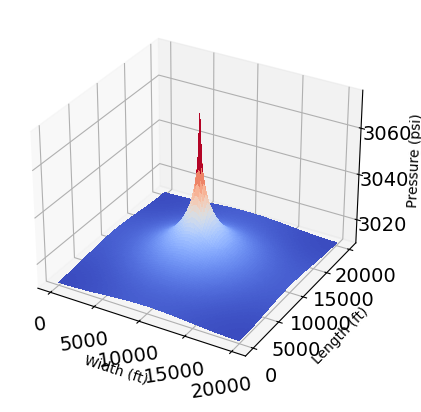

In [22]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm, colorbar

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X.T, Y.T, P_time_50, rstride=1, cstride=1, cmap=cm.coolwarm,
                linewidth=0, antialiased=False)

ax.set_xlabel('Width (ft)')
ax.set_ylabel('Length (ft)')
ax.set_zlabel('Pressure (psi)')

plt.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=8)
plt.show()